In [1]:
!pip install conllu
!pip install tqdm

import tarfile
from conllu import parse_incr
import os
from tqdm import tqdm
import pickle
import torch
import random
import numpy as np

data_path_in = '/kaggle/input/'
data_path_out = '/kaggle/working/'
treebank_tar = os.path.join(data_path_in, 'ud-treebanks-v2.14.tgz')

with tarfile.open(treebank_tar, 'r:gz') as tar:
    tar.extractall(path=data_path_out)

In [2]:
def get_language_folders(language):
    language = language.capitalize()
    extracted_path = os.path.join(data_path_out, 'ud-treebanks-v2.14')
    folders = [folder for folder in os.listdir(extracted_path) if folder.startswith(f'UD_{language}-')] 
    return folders

    
def get_conllu_filepaths(language_folders): # get .conllu files from all language folders for the language
    filepaths = []
        
    for folder in language_folders:
        folder_path = os.path.join(data_path_out, 'ud-treebanks-v2.14', folder) 
        for file_name in os.listdir(folder_path):
            if file_name.endswith('.conllu'):
                filepaths.append(os.path.join(folder_path, file_name))
    
    return filepaths


def create_sentence_noun_gender_dict(language):
    sentence_noun_gender_dict = []
    language_folders = get_language_folders(language)
    print(language_folders, len(language_folders))
    filepaths = get_conllu_filepaths(language_folders)

    for filepath in tqdm(filepaths, desc=f"Processing files for {language}", unit="file"):
        with open(filepath, 'r', encoding='utf-8') as f:
            sentences = parse_incr(f)  # parse the conllu file incrementally
            for tokenlist in sentences:
                sentence = " ".join(token['form'] for token in tokenlist)  # Original sentence
                for idx, token in enumerate(tokenlist):
                    if token['upostag'] == 'NOUN':
                        noun = token['form']
                        lemma = token['lemma']
                        feats = token.get('feats')
                        if feats is not None:
                            gender = feats.get('Gender', None)  # Extract gender
                            if gender in ['Masc', 'Fem', 'Neut', 'Com']:
                                if gender in ['Masc', 'Fem']:
                                    gender = 'Com'
                                sentence_noun_gender_dict.append({
                                    'sent': sentence,  # Full sentence
                                    'noun': noun,  # Direct token form
                                    'lemma': lemma, # Lemma of noun
                                    'gender': gender  # Gender of the noun
                                        })
    print(f"Extracted {len(sentence_noun_gender_dict)} entries for {language}. Filtering out sentences with multiple occurrences of target nouns.\n")

    filtered_results = []
    for entry in sentence_noun_gender_dict:
        noun = entry['noun']
        sentence = entry['sent']
        # Only include if the noun appears exactly once in the sentence
        if sentence.count(noun) == 1:
            filtered_results.append(entry)
        
    sentence_noun_gender_dict = filtered_results
    return sentence_noun_gender_dict

In [3]:
german_dict = create_sentence_noun_gender_dict('German')
danish_dict = create_sentence_noun_gender_dict('Danish')

['UD_German-LIT', 'UD_German-PUD', 'UD_German-GSD', 'UD_German-HDT'] 4


Processing files for German: 100%|██████████| 8/8 [01:09<00:00,  8.65s/file]


Extracted 739510 entries for German. Filtering out sentences with multiple occurrences of target nouns.

['UD_Danish-DDT'] 1


Processing files for Danish: 100%|██████████| 3/3 [00:01<00:00,  1.62file/s]

Extracted 18611 entries for Danish. Filtering out sentences with multiple occurrences of target nouns.



In [4]:
print(len(danish_dict))
print(len(german_dict)) 

print(german_dict[0:2])
print(danish_dict[0:2])

sample_size = len(danish_dict)
german_dict = random.sample(german_dict, sample_size)
print(len(german_dict))

17742
712037
[{'sent': 'Wer viel Geist hat , macht viel aus seinem Leben .', 'noun': 'Leben', 'lemma': 'Leben', 'gender': 'Neut'}, {'sent': 'Nichts ist zur zu der wahren Religiosität unentbehrlicher als ein Mittelglied , das uns mit der Gottheit verbindet .', 'noun': 'Mittelglied', 'lemma': 'Mittelglied', 'gender': 'Neut'}]
[{'sent': 'Hvor kommer julemanden fra ?', 'noun': 'julemanden', 'lemma': 'julemand', 'gender': 'Com'}, {'sent': 'Flertallet lever stadig under plastikstykker eller tæpper , som de har spændt ud over nogle stokke som et improviseret telt .', 'noun': 'Flertallet', 'lemma': 'flertal', 'gender': 'Neut'}]
17742


German Gender Percentages: {'Neut': 23.537368955021982, 'Com': 76.46263104497801}
Danish Gender Percentages: {'Com': 69.80610979596437, 'Neut': 30.193890204035622}


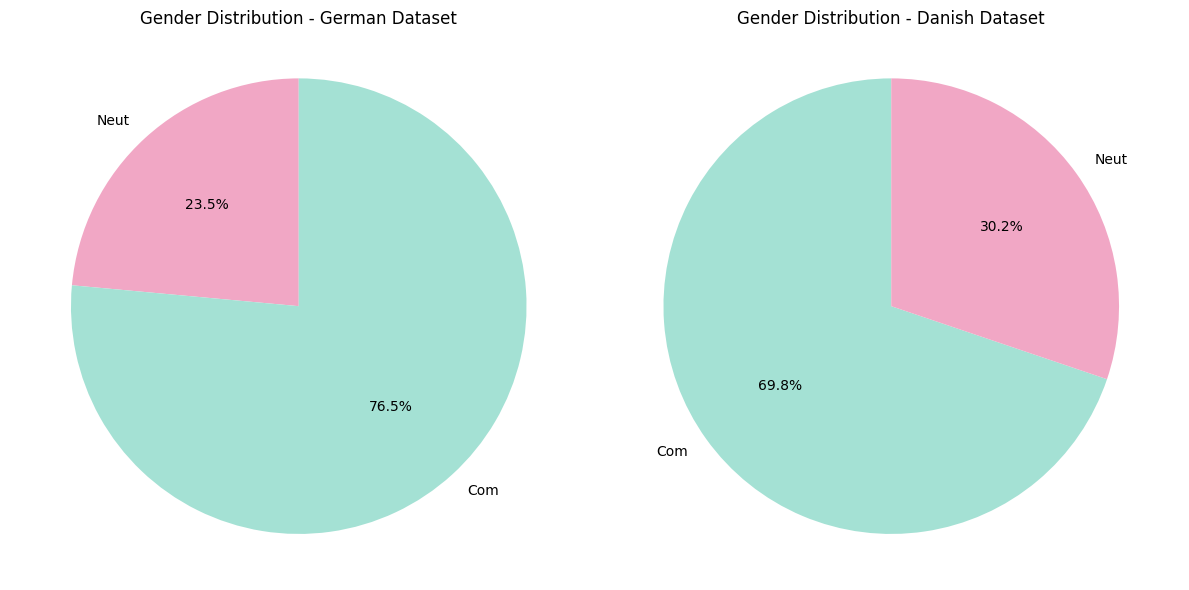

German Fem: 0%, Masc: 0%, Neut: 30.193890204035622%, Com: 69.80610979596437%


In [6]:
import matplotlib.pyplot as plt
from collections import Counter

def plot_gender_distribution(data, title, ax, color_mapping):
    gender_counts = Counter(item['gender'] for item in data)
    
    total = sum(gender_counts.values())
    percentages = {gender: count / total * 100 for gender, count in gender_counts.items()}
    labels = percentages.keys()
    sizes = percentages.values()

    colors = [color_mapping.get(gender, '#FFFFFF') for gender in labels]

    ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90,
           colors=colors)  
    ax.axis('equal') 
    ax.set_title(title)
    
    return percentages

color_mapping = {
    'Fem': '#D1B2E1',    # Light Pastel Purple
    'Masc': '#A4C8E1',   # Light Pastel Blue
    'Neut': '#F1A7C5',   # Light Pastel Magenta
    'Com': '#A4E1D4'     # Light Pastel Teal
}

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot for German data
danish_percentages = plot_gender_distribution(german_dict, 'Gender Distribution - German Dataset', axs[0], color_mapping)
print("German Gender Percentages:", danish_percentages)

# Plot for Danish data
danish_percentages = plot_gender_distribution(danish_dict, 'Gender Distribution - Danish Dataset', axs[1], color_mapping)
print("Danish Gender Percentages:", danish_percentages)

plt.tight_layout()
plt.show()

# Extract percentages for German data
ge_fem_per = danish_percentages.get('Fem', 0)
ge_masc_per = danish_percentages.get('Masc', 0)
ge_neut_per = danish_percentages.get('Neut', 0)
ge_common_per = danish_percentages.get('Com', 0)

# Output the percentages
print(f"German Fem: {ge_fem_per}%, Masc: {ge_masc_per}%, Neut: {ge_neut_per}%, Com: {ge_common_per}%")

In [7]:
import random
import numpy as np
from sklearn.model_selection import train_test_split

In [8]:
gender_mapping = {
    'Masc': 0,
    'Fem': 1,
    'Neut': 2,
    'Com': 3
}


def split_dataset(data, noun_form, train_size=0.8, val_size=0.1, test_size=0.1):
    random.shuffle(data) 
    
    # split the data into train, test, and validation set 
    train_data, rem_data = train_test_split(data, test_size=(val_size + test_size))
    val_data, test_data = train_test_split(rem_data, test_size=test_size / (val_size + test_size))
    
    # Extract sentences and labels
    train_sent = [item['sent'] for item in train_data]
    val_sent = [item['sent'] for item in val_data]
    test_sent = [item['sent'] for item in test_data]

    train_labels = [gender_mapping[item['gender']] for item in train_data]
    val_labels = [gender_mapping[item['gender']] for item in val_data]
    test_labels = [gender_mapping[item['gender']] for item in test_data]

    if noun_form == "full":
        train_nouns = [item['noun'] for item in train_data]
        val_nouns = [item['noun'] for item in val_data]
        test_nouns = [item['noun'] for item in test_data]
        
    elif noun_form == "lemma":
        train_nouns = [item['lemma'] for item in train_data]
        val_nouns = [item['lemma'] for item in val_data]
        test_nouns = [item['lemma'] for item in test_data]
    else:
        raise ValueError

    return (train_sent, train_labels, train_nouns,
            val_sent, val_labels, val_nouns,
            test_sent, test_labels, test_nouns)


(ge_train_X, ge_train_y, ge_train_nouns, 
ge_val_X, ge_val_y,ge_val_nouns,
ge_test_X, ge_test_y, ge_test_nouns) = split_dataset(german_dict, "full") # split for German


(da_train_X, da_train_y, da_train_nouns, 
da_val_X, da_val_y, da_val_nouns,
da_test_X, da_test_y, da_test_nouns) = split_dataset(danish_dict, "full")


In [9]:
print(len(ge_train_X))
print(len(ge_val_X))
print(len(ge_test_X))

print(len(da_train_X))
print(len(da_val_X))
print(len(da_test_X))


print(f"sentence: {da_train_X[0]}")
print(f"gender label: {da_train_y[0]}")
print(f"noun: {da_train_nouns[0]}")

14193
1774
1775
14193
1774
1775
sentence: Jeg rejste mig smed min blomsterbuket i hovedet på hende - ikke unødvendigt hårdt - og gik ud ad døren , som jeg smækkede med et mindre eftertryk .
gender label: 2
noun: eftertryk


In [10]:
import torch
import torch.nn as nn
from transformers import BertTokenizer, BertModel

 
class GenderClassifier(nn.Module):
    def __init__(self,layer, num_labels=4, hidden_size=768):
        super(GenderClassifier, self).__init__()
        self.classifier = nn.Linear(hidden_size, num_labels)  # add classification layer on top
        self.layer = layer # layer we want to pass to classification head
        
    
    def forward(self, noun_embeddings): 
        # classify based on the noun's embedding
        selected_layer_embedding = noun_embeddings[:, self.layer, :] 
        logits = self.classifier(selected_layer_embedding)  
        return logits

In [11]:
from torch.utils.data import DataLoader, TensorDataset
import torch
from transformers import BertTokenizer, BertModel

# Load tokenizer and model
tokenizer = BertTokenizer.from_pretrained("bert-base-multilingual-cased")
bert_model = BertModel.from_pretrained("bert-base-multilingual-cased", output_hidden_states=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bert_model.to(device)



def encode_data_and_get_lemma_embeddings(tokenizer, lemmas, batch_size=32):
    """
    Tokenizes lemmas in batches and computes their embeddings using BERT (without sentence context).
    
    Parameters:
    - tokenizer: mBERT tokenizer
    - lemmas: list of lemmas to process
    - batch_size: number of lemmas to process at once
    
    Returns:
    - torch.Tensor: tensor of lemma embeddings [num_lemmas, num_layers, hidden_size]
    """
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    lemma_embeddings = []
    
    for i in range(0, len(lemmas), batch_size):
        batch_lemmas = lemmas[i:i + batch_size]
        #print(i)
        tokenized_inputs = tokenizer(batch_lemmas, return_tensors='pt', padding=True, truncation=False)
        tokenized_inputs = {key: val.to(device) for key, val in tokenized_inputs.items()} 
        
        with torch.no_grad():
            outputs = bert_model(input_ids=tokenized_inputs['input_ids'], 
                                 attention_mask=tokenized_inputs['attention_mask'], 
                                 output_hidden_states=True)
            all_layer_embeddings = outputs.hidden_states  # [num_layers, batch_size, seq_len, hidden_size]
            batch_lemma_embeddings = torch.stack([layer.mean(dim=1) for layer in all_layer_embeddings]) # average across all sub tokens
            #batch_lemma_embeddings = torch.stack([layer[:, 0, :] for layer in all_layer_embeddings])  # First token embedding
            # take CLS token or first sub-token embedding
            lemma_embeddings.append(batch_lemma_embeddings)
            
    # Concatenate along the batch dimension
    lemma_embeddings = torch.cat(lemma_embeddings, dim=1)  # [num_layers, total_lemmas, hidden_size]
    
    # Transpose to: [total_lemmas, num_layers, hidden_size]
    lemma_embeddings = lemma_embeddings.permute(1, 0, 2)  # Swap batch_size and num_layers dimensions

    #print(lemma_embeddings.shape) # shape [num_lemmas, num_layers, hidden_size]
    return lemma_embeddings

def find_subtoken_pos_t(noun_ids, sent_ids):
    """Returns the start and end index of a noun's subtokens in the sentence's token IDs."""
    noun_length = noun_ids.size(0)
    
    # Loop through the sentence to find the noun
    for i in range(sent_ids.size(0) - noun_length + 1):
        if torch.equal(sent_ids[i:i + noun_length], noun_ids):
            return i, i + noun_length  # Return the start and end index (end is exclusive)
    return None 

def encode_data_and_compute_noun_embeddings(tokenizer, texts, nouns, batch_size=32): # with batch processing
    """
    Tokenizes texts in batches and computes BERT noun embeddings for each text.
    
    Parameters:
    - tokenizer: mBERT tokenizer
    - texts: list of sentences to process
    - nouns: list of target nouns (one for each sentence)
    - batch_size: number of sentences to process at once
    
    Returns:
    - torch.Tensor: tensor of noun embeddings [batch_size, num_layers, hidden_size]
    """

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    noun_embeddings = []

    # Loop through `texts` in batches
    for i in range(0, len(texts), batch_size):
        # Select the current batch
        batch_texts = texts[i:i + batch_size]
        batch_nouns = nouns[i:i + batch_size]
        
        # Tokenize the batch
        tokenized_inputs = tokenizer(batch_texts, return_tensors='pt', padding=True, truncation=False)
        tokenized_inputs = {key: val.to(device) for key, val in tokenized_inputs.items()} 


        with torch.no_grad():
            outputs = bert_model(input_ids=tokenized_inputs['input_ids'], 
                                 attention_mask=tokenized_inputs['attention_mask'], 
                                 output_hidden_states=True)
            all_layer_embeddings = outputs.hidden_states  # [num_layers, batch_size, seq_len, hidden_size]

        # process each sentence and noun in the batch
        for j, noun in enumerate(batch_nouns):  # iterate over sentences in the batch
            noun_token_ids = tokenizer.encode(noun, add_special_tokens=False)
            valid_token_ids = torch.tensor(noun_token_ids).to(device)

            #find position of noun in the tokenized sentence
            subtoken_pos = find_subtoken_pos_t(valid_token_ids, tokenized_inputs['input_ids'][j])
            if subtoken_pos is None:
                print(f"Not found for {valid_token_ids} in {tokenized_inputs['input_ids'][j]}")
                continue
            
            subtoken_pos_start, subtoken_pos_end = subtoken_pos

            # average subtoken embeddings across layers for the noun and stack embeddings
            stacked_layer_embeddings = torch.stack([layer[j, subtoken_pos_start:subtoken_pos_end, :].mean(dim=0)
                                                    for layer in all_layer_embeddings])
            noun_embeddings.append(stacked_layer_embeddings)  # [num_layers, hidden_size]
        
        del tokenized_inputs
        torch.cuda.empty_cache()

    return torch.stack(noun_embeddings)  # Shape: [num_texts, num_layers, hidden_size]


def create_data_loader(noun_embeddings, labels, batch_size=32):
    """Creates a DataLoader for noun embeddings and labels."""
    labels_tensor = torch.tensor(labels).to(device) 
    dataset = TensorDataset(noun_embeddings, labels_tensor)
    return DataLoader(dataset, batch_size=batch_size) 


batch_size = 32

# Encode and create data loaders for training, validation, and test sets (CONTEXTUALIZED EMBEDDINGS), comment out if training is conducted using lemma embeddings

'''
ge_train_noun_embeddings = encode_data_and_compute_noun_embeddings(tokenizer, ge_train_X, ge_train_nouns)
ge_train_data_loader = create_data_loader(ge_train_noun_embeddings, ge_train_y, batch_size)

ge_val_noun_embeddings = encode_data_and_compute_noun_embeddings(tokenizer, ge_val_X, ge_val_nouns)
ge_val_data_loader = create_data_loader(ge_val_noun_embeddings, ge_val_y, batch_size)

ge_test_noun_embeddings = encode_data_and_compute_noun_embeddings(tokenizer, ge_test_X, ge_test_nouns)
ge_test_data_loader = create_data_loader(ge_test_noun_embeddings, ge_test_y, batch_size)

# Generate noun embeddings and create data loaders for training, validation, and test sets
#gr_train_noun_embeddings = encode_data_and_compute_noun_embeddings(tokenizer, gr_train_X, gr_train_nouns)
#gr_train_data_loader = create_data_loader(gr_train_noun_embeddings, gr_train_y, batch_size)

#gr_val_noun_embeddings = encode_data_and_compute_noun_embeddings(tokenizer, gr_val_X, gr_val_nouns)
#gr_val_data_loader = create_data_loader(gr_val_noun_embeddings, gr_val_y, batch_size)

gr_test_noun_embeddings = encode_data_and_compute_noun_embeddings(tokenizer, gr_test_X, gr_test_nouns)
gr_test_data_loader = create_data_loader(gr_test_noun_embeddings, gr_test_y, batch_size)'''



# Encode and create data loaders for training, validation, and test sets (LEMMA EMBEDDINGS)

ge_train_noun_embeddings = encode_data_and_get_lemma_embeddings(tokenizer, ge_train_nouns)
ge_train_data_loader = create_data_loader(ge_train_noun_embeddings, ge_train_y, batch_size)

ge_val_noun_embeddings = encode_data_and_get_lemma_embeddings(tokenizer, ge_val_nouns)
ge_val_data_loader = create_data_loader(ge_val_noun_embeddings, ge_val_y, batch_size)

ge_test_noun_embeddings = encode_data_and_get_lemma_embeddings(tokenizer, ge_test_nouns)
ge_test_data_loader = create_data_loader(ge_test_noun_embeddings, ge_test_y, batch_size)

da_test_noun_embeddings = encode_data_and_get_lemma_embeddings(tokenizer, da_test_nouns)
da_test_data_loader = create_data_loader(da_test_noun_embeddings, da_test_y, batch_size)

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

In [12]:
from transformers import AdamW
import torch.nn.functional as F
from sklearn.metrics import accuracy_score

def train_epoch(model, data_loader, loss_fn, optimizer, device):
    model.train()
    total_loss, total_correct = 0, 0
    
    for batch in data_loader:
        noun_embeddings, labels = [x.to(device) for x in batch]
        
        
        optimizer.zero_grad()
        # pass the nouns and positions to the model
        outputs = model(noun_embeddings)
        loss = loss_fn(outputs, labels)
        
        total_loss += loss.item()
        
        # backward pass and optimization
        loss.backward()
        optimizer.step()
        
        # calculate accuracy
        preds = torch.argmax(outputs, dim=1)
        total_correct += torch.sum(preds == labels).item()
    
    avg_loss = total_loss / len(data_loader)
    accuracy = total_correct / len(data_loader.dataset)
    return avg_loss, accuracy


def eval_model(model, data_loader, loss_fn, device):
    model.eval()  # Set the model to evaluation mode
    total_loss = 0
    predictions = []
    true_labels = []

    with torch.no_grad():  # Disable gradient calculation
        for batch in data_loader:
            noun_embeddings, labels = [x.to(device) for x in batch]
            
            # Forward pass
            outputs = model(noun_embeddings)
            loss = loss_fn(outputs, labels)
            total_loss += loss.item()
            
            # Collect predictions and true labels
            preds = torch.argmax(outputs, dim=1)
            predictions.extend(preds.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())
    
    # Calculate average loss for the validation set
    avg_loss = total_loss / len(data_loader)

    # Calculate F1 score (macro-averaged by default)
    f1 = f1_score(true_labels, predictions, average='macro')

    return avg_loss, f1



In [13]:
import matplotlib.pyplot as plt
from tqdm import tqdm  # Import tqdm
from sklearn.metrics import f1_score


def clear_old_model(model): # delete model from GPU
    model.to('cpu')
    del model
    torch.cuda.empty_cache()
    #gc.collect()

def train_and_evaluate(layer_number, random_seed, patience=5):
    torch.manual_seed(random_seed)
    random.seed(random_seed)
    np.random.seed(random_seed)
    
    model = GenderClassifier(num_labels=4, layer=layer_number)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')  # auslagern
    model.to(device)

    # Adjusted loss function with class weights
    weights = torch.tensor([ge_masc_per, ge_fem_per, ge_neut_per, ge_common_per]).to(device)
    loss_fn = nn.CrossEntropyLoss(weight=weights)

    optimizer = AdamW(model.parameters(), lr=5e-5)  # Optimizer
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)  # Reduce LR every 10 epochs
    num_epochs = 30
    best_val_f1 = 0
    patience_counter = 0
    
    # Check if a previous model state exists and delete it
    model_filename = f"best_model_state_layer_{layer_number}.bin"
    if os.path.exists(model_filename):
        os.remove(model_filename)

    # Initialize lists to store loss and F1 scores for plotting
    train_losses = []
    train_f1s = []
    val_losses = []
    val_f1s = []

    # Training loop
    for epoch in range(num_epochs):
        print(f"Epoch {epoch + 1}/{num_epochs}")

        # Training phase
        model.train() 
        total_loss = 0
        true_labels = []
        preds = []

        for batch in tqdm(ge_train_data_loader, desc="Training", unit="batch"):
            noun_embeddings, labels = [x.to(device) for x in batch]

            optimizer.zero_grad()  # Clear previous gradients
            outputs = model(noun_embeddings)
            loss = loss_fn(outputs, labels)
            total_loss += loss.item()  # Accumulate loss
            loss.backward()
            optimizer.step()

            batch_preds = torch.argmax(outputs, dim=1)
            preds.extend(batch_preds.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

        # Calculate average loss and F1 score for the epoch
        avg_loss = total_loss / len(ge_train_data_loader)
        train_losses.append(avg_loss)  # Store training loss
        train_f1 = f1_score(true_labels, preds, average='macro')
        train_f1s.append(train_f1)  # Store training F1 score
        print(f"Train Loss: {avg_loss:.4f}, Train F1: {train_f1:.4f}")

        # Validation phase
        val_loss, val_f1 = eval_model(model, ge_val_data_loader, loss_fn, device)  # Using eval_model for F1 score
        val_losses.append(val_loss)  # Store validation loss
        val_f1s.append(val_f1)  # Store validation F1 score
        print(f"Val Loss: {val_loss:.4f}, Val F1: {val_f1:.4f}")

        # Early stopping based on validation F1 score
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), model_filename)  # Save the best model
            patience_counter = 0  # Reset patience counter
        else:
            patience_counter += 1

        # If patience is exceeded, stop training early
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

        # Update the learning rate scheduler
        scheduler.step()

    # Adjust the number of epochs for plotting based on early stopping
    actual_epochs = len(train_losses)  # The actual number of epochs trained
    
    pastel_pink = '#FFB3BA'  
    pastel_purple = '#D5C6E0'

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(range(1, actual_epochs + 1), train_losses, label='Train Loss', marker='o', color=pastel_pink)
    plt.plot(range(1, actual_epochs + 1), val_losses, label='Validation Loss', marker='o', color=pastel_purple)
    plt.title(f'Loss Over Epochs for Layer {layer_number}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.plot(range(1, actual_epochs + 1), train_f1s, label='Train F1', marker='o', color=pastel_pink)
    plt.plot(range(1, actual_epochs + 1), val_f1s, label='Validation F1', marker='o', color=pastel_purple)
    plt.title(f'F1 Over Epochs for Layer {layer_number}')
    plt.xlabel('Epochs')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()

    return model, train_f1s, val_f1s

In [14]:
import torch
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def eval_test_model(model, data_loader, loss_fn, device):
    model.eval()  # Set the model to evaluation mode
    total_loss = 0
    predictions = []
    true_labels = []

    with torch.no_grad():  # Disable gradient calculation
        for batch in data_loader:
            noun_embeddings, labels = [x.to(device) for x in batch]
            
            # Forward pass
            outputs = model(noun_embeddings)
            loss = loss_fn(outputs, labels)
            total_loss += loss.item()  # Accumulate loss
            
            # Collect predictions and true labels
            preds = torch.argmax(outputs, dim=1)
            predictions.extend(preds.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    # Calculate average loss for the test set
    avg_loss = total_loss / len(data_loader)

    # Calculate F1 score (macro-averaged by default)
    f1 = f1_score(true_labels, predictions, average='macro')

    return avg_loss, f1, predictions, true_labels


# Generate and plot confusion matrix

def plot_cm(test_true_labels, test_predictions, layer):
    cm = confusion_matrix(test_true_labels, test_predictions)

    # Plotting confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='BuPu', 
                xticklabels=['Masculine', 'Feminine', 'Neuter', 'Common'], 
                yticklabels=['Masculine', 'Feminine', 'Neuter', 'Common'])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title(f'Confusion Matrix on Test Set for layer {layer}')
    plt.show()
    
#plot_cm(test_true_labels, test_predictions)

/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Training for layer 0 with seed 42:
Epoch 1/30


Training: 100%|██████████| 444/444 [00:00<00:00, 614.32batch/s]


Train Loss: 0.6258, Train F1: 0.2151
Val Loss: 0.4575, Val F1: 0.4307
Epoch 2/30


Training: 100%|██████████| 444/444 [00:00<00:00, 818.14batch/s]


...

Train Loss: 0.3631, Train F1: 0.4338
Val Loss: 0.3725, Val F1: 0.4307
Epoch 5/30


Training: 100%|██████████| 444/444 [00:00<00:00, 768.11batch/s]


Train Loss: 0.3538, Train F1: 0.4338
Val Loss: 0.3635, Val F1: 0.4307
Epoch 6/30


Training: 100%|██████████| 444/444 [00:00<00:00, 718.57batch/s]


Train Loss: 0.3462, Train F1: 0.4338
Val Loss: 0.3556, Val F1: 0.4307
Early stopping triggered.


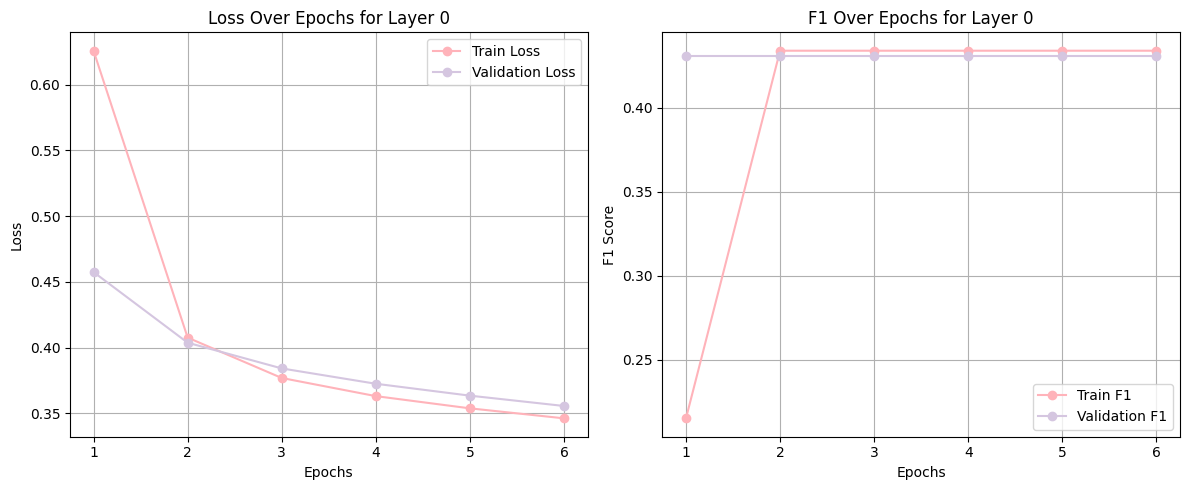

Test F1 on German: 0.4318181818181818


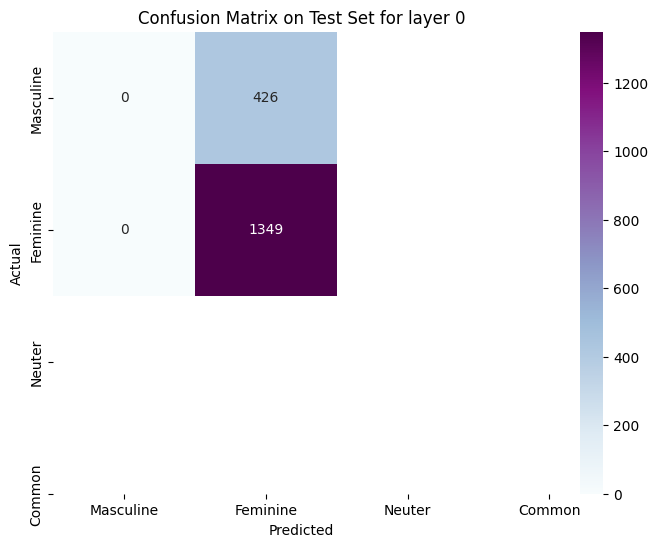

Test F1 on Danish: 0.40476190476190477


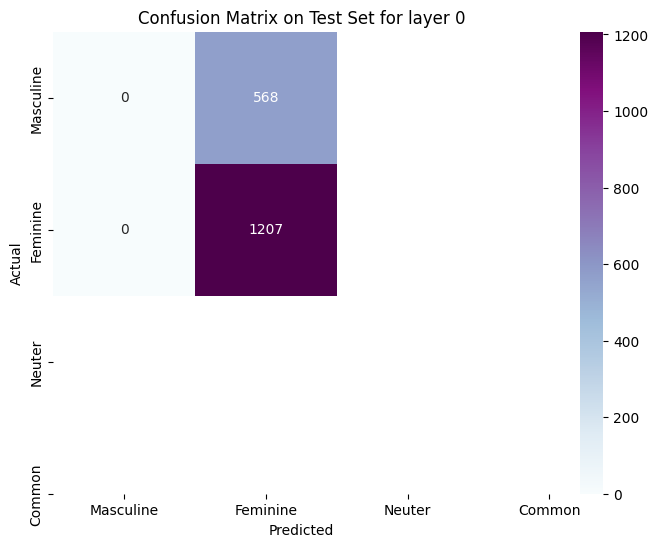

/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Training for layer 0 with seed 123:
Epoch 1/30


Training: 100%|██████████| 444/444 [00:00<00:00, 706.29batch/s]


Train Loss: 0.5772, Train F1: 0.2162
Val Loss: 0.4462, Val F1: 0.4307
Epoch 2/30


Training: 100%|██████████| 444/444 [00:00<00:00, 746.82batch/s]


...

Train Loss: 0.3611, Train F1: 0.4338
Val Loss: 0.3698, Val F1: 0.4307
Epoch 5/30


Training: 100%|██████████| 444/444 [00:00<00:00, 796.09batch/s]


Train Loss: 0.3522, Train F1: 0.4338
Val Loss: 0.3611, Val F1: 0.4307
Epoch 6/30


Training: 100%|██████████| 444/444 [00:00<00:00, 800.11batch/s]


Train Loss: 0.3447, Train F1: 0.4338
Val Loss: 0.3535, Val F1: 0.4307
Early stopping triggered.


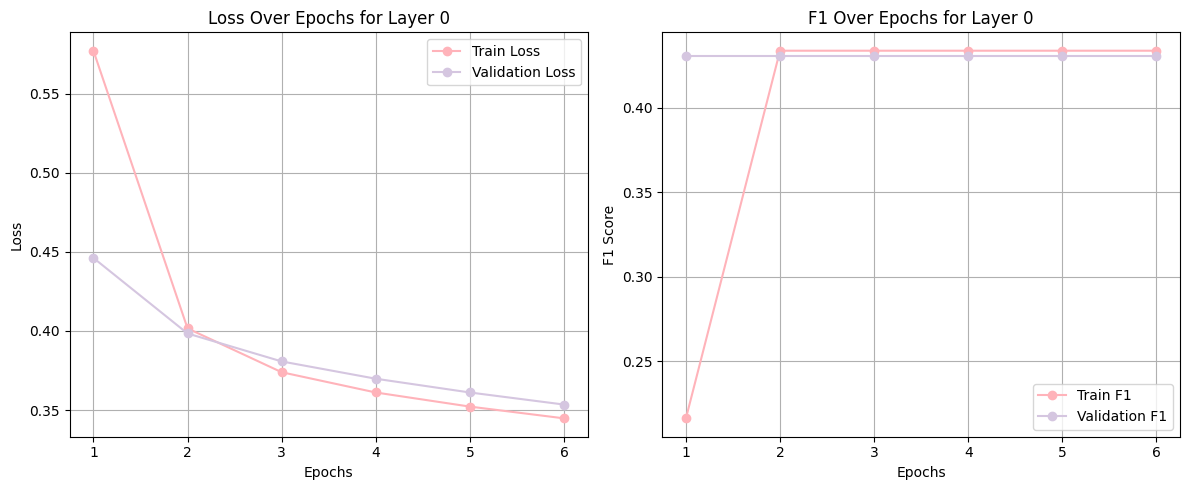

Test F1 on German: 0.4318181818181818


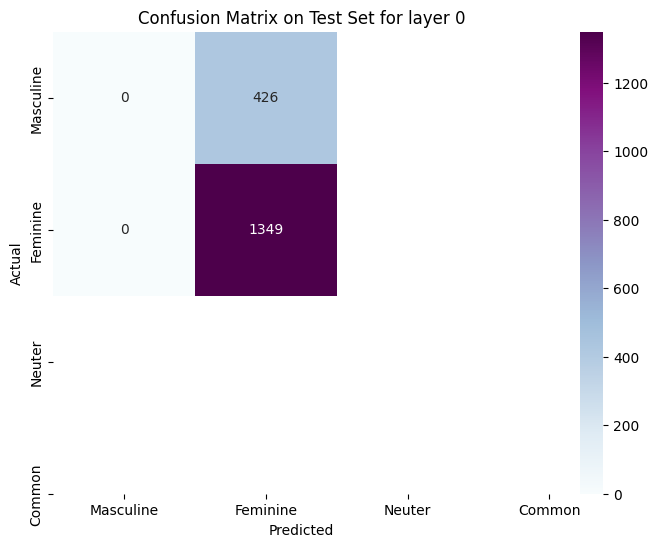

Test F1 on Danish: 0.40476190476190477


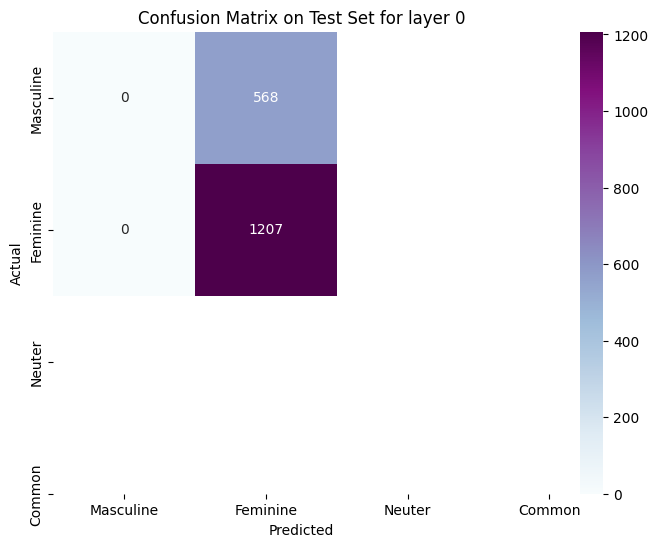

/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Training for layer 0 with seed 456:
Epoch 1/30


Training: 100%|██████████| 444/444 [00:00<00:00, 766.09batch/s]


Train Loss: 0.6355, Train F1: 0.2146
Val Loss: 0.4542, Val F1: 0.4307
Epoch 2/30


Training: 100%|██████████| 444/444 [00:00<00:00, 729.35batch/s]


...

Train Loss: 0.3644, Train F1: 0.4338
Val Loss: 0.3721, Val F1: 0.4307
Epoch 5/30


Training: 100%|██████████| 444/444 [00:00<00:00, 804.01batch/s]


Train Loss: 0.3553, Train F1: 0.4338
Val Loss: 0.3633, Val F1: 0.4307
Epoch 6/30


Training: 100%|██████████| 444/444 [00:00<00:00, 811.61batch/s]


Train Loss: 0.3478, Train F1: 0.4338
Val Loss: 0.3557, Val F1: 0.4307
Early stopping triggered.


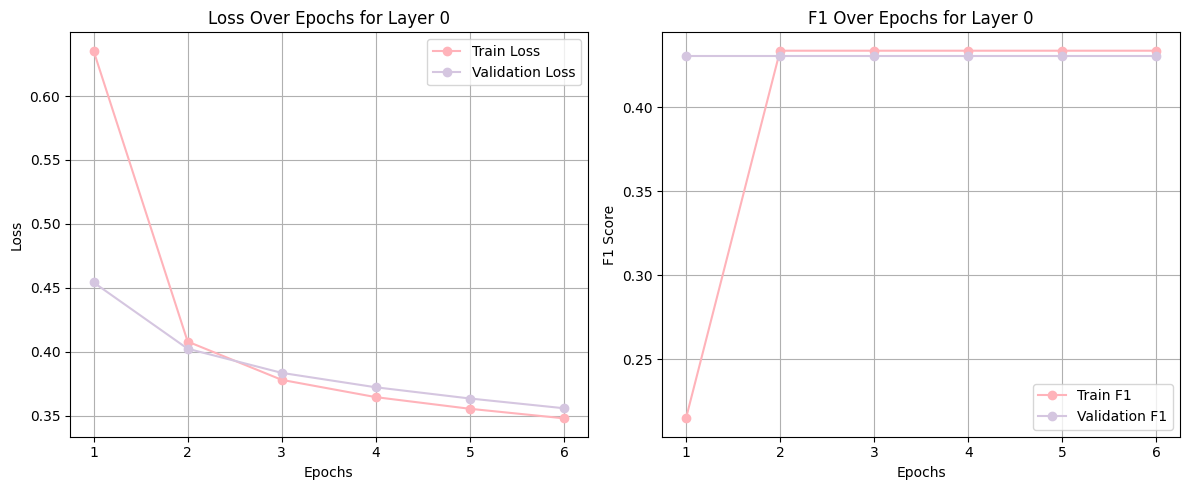

Test F1 on German: 0.4318181818181818


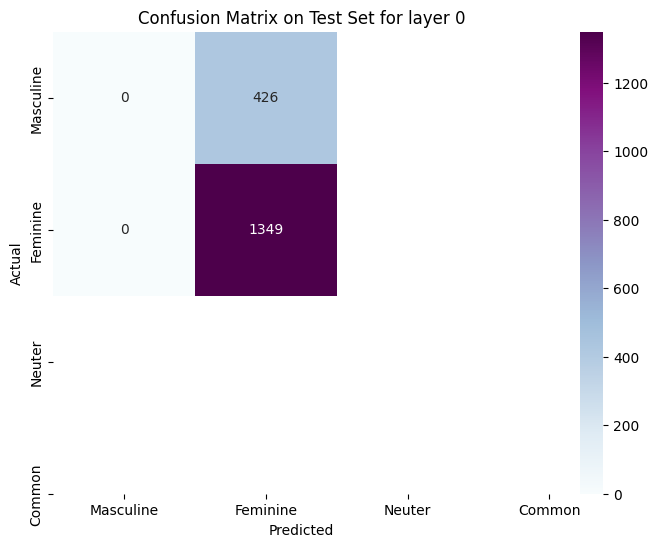

Test F1 on Danish: 0.40476190476190477


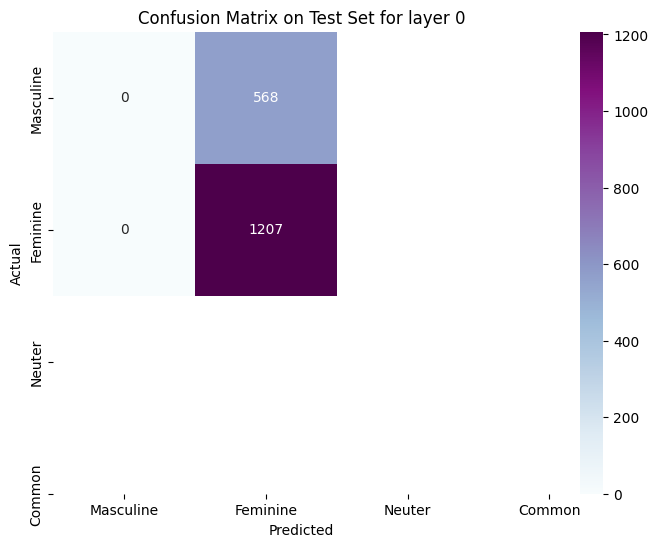

/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Layer 0: [0.4047619047619048]
Training for layer 1 with seed 42:
Epoch 1/30


Training: 100%|██████████| 444/444 [00:00<00:00, 808.14batch/s]


Train Loss: 0.6810, Train F1: 0.2126
Val Loss: 0.4633, Val F1: 0.4307
Epoch 2/30


Training: 100%|██████████| 444/444 [00:00<00:00, 786.04batch/s]


...

Train Loss: 0.3597, Train F1: 0.4338
Val Loss: 0.3666, Val F1: 0.4307
Epoch 5/30


Training: 100%|██████████| 444/444 [00:00<00:00, 790.09batch/s]


Train Loss: 0.3495, Train F1: 0.4338
Val Loss: 0.3569, Val F1: 0.4307
Epoch 6/30


Training: 100%|██████████| 444/444 [00:00<00:00, 808.20batch/s]


Train Loss: 0.3414, Train F1: 0.4338
Val Loss: 0.3486, Val F1: 0.4307
Early stopping triggered.


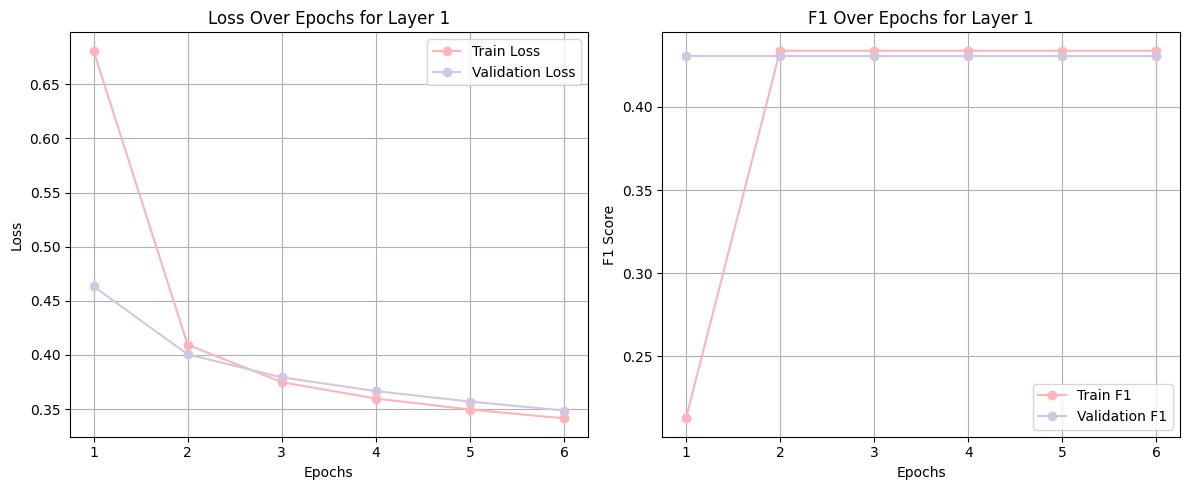

Test F1 on German: 0.4318181818181818


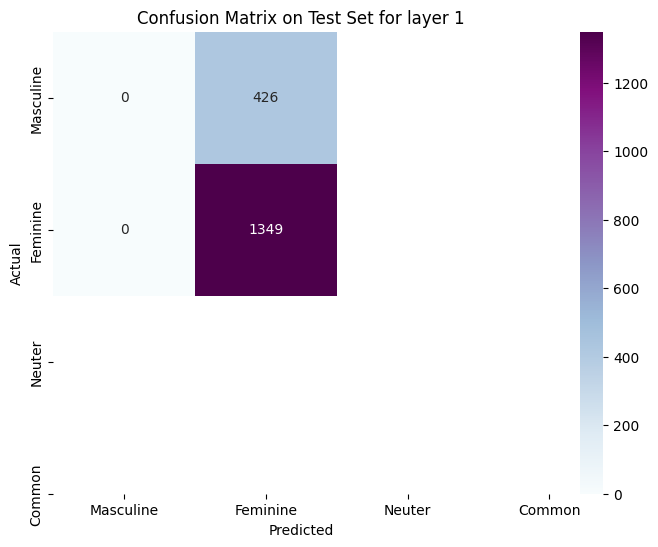

Test F1 on Danish: 0.40476190476190477


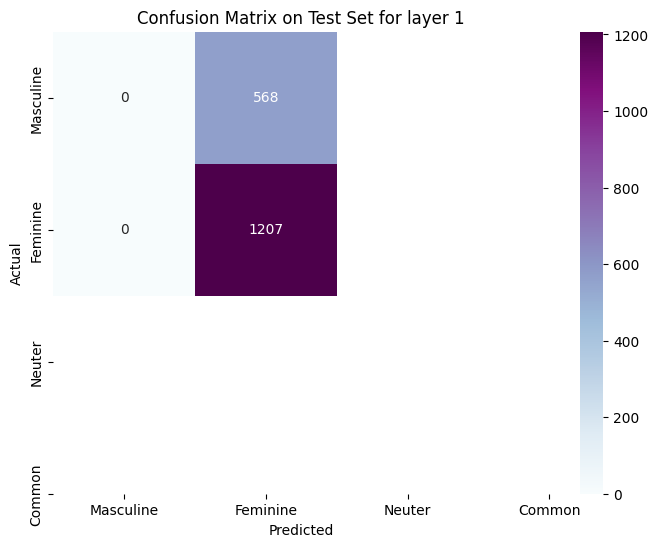

/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Training for layer 1 with seed 123:
Epoch 1/30


Training: 100%|██████████| 444/444 [00:00<00:00, 782.99batch/s]


Train Loss: 0.6106, Train F1: 0.2879
Val Loss: 0.4449, Val F1: 0.4307
Epoch 2/30


Training: 100%|██████████| 444/444 [00:00<00:00, 780.86batch/s]


...

Training: 100%|██████████| 444/444 [00:00<00:00, 799.57batch/s]


Train Loss: 0.3573, Train F1: 0.4338
Val Loss: 0.3637, Val F1: 0.4307
Epoch 5/30


Training: 100%|██████████| 444/444 [00:00<00:00, 763.69batch/s]


Train Loss: 0.3478, Train F1: 0.4338
Val Loss: 0.3546, Val F1: 0.4307
Epoch 6/30


Training:   0%|          | 0/444 [00:00<?, ?batch/s]

In [ ]:
import time

start_time = time.time()

    
selected_layers = list(range(13))

train_f1s_ge = []
val_f1s_ge = []
test_f1s_ge = []  # list to store test F1 for German
test_f1s_da = []  # list to store test F1 for Danish

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
weights = torch.tensor([ge_masc_per, ge_fem_per, ge_neut_per, ge_common_per]).to(device)  # class distribution for masc, fem, neut, and common
loss_fn = nn.CrossEntropyLoss(weight=weights)  # weighted loss function because of the class imbalance towards feminine

seed_values = [42, 123, 456]  # list of seeds for random initialization

for layer in selected_layers:
    train_f1_ge_seed = []
    val_f1_ge_seed = []
    test_f1_ge_seed = []
    test_f1_da_seed = []

    for seed_value in seed_values:
        # Set the random seed for reproducibility
        torch.manual_seed(seed_value)
        random.seed(seed_value)
        np.random.seed(seed_value)
        
        print(f"Training for layer {layer} with seed {seed_value}:")
        current_model, train_f1, val_f1 = train_and_evaluate(layer,seed_value)

        train_f1_ge_seed.append(train_f1)
        val_f1_ge_seed.append(val_f1)

        test_loss, test_f1, test_predictions, test_true_labels = eval_test_model(current_model, ge_test_data_loader, loss_fn, device)
        test_f1_ge_seed.append(test_f1)
        print(f"Test F1 on German: {test_f1}")
        plot_cm(test_true_labels, test_predictions, layer)  # Confusion Matrix for German


        test_loss_da, test_f1_da, test_predictions_da, test_true_labels_da = eval_test_model(current_model, da_test_data_loader, loss_fn, device)
        test_f1_da_seed.append(test_f1_da)
        print(f"Test F1 on Danish: {test_f1_da}")
        plot_cm(test_true_labels_da, test_predictions_da, layer)  # Confusion Matrix for Danish

        # Clear the model to free up memory
        clear_old_model(current_model)

    avg_test_f1_ge = np.mean(test_f1_ge_seed)
    avg_test_f1_da = np.mean(test_f1_da_seed)
    test_f1s_ge.append(avg_test_f1_ge)
    test_f1s_da.append(avg_test_f1_da)
    print(f"Layer 0: {test_f1s_da}")
    

end_time = time.time()

# Calculate and print the total time taken
total_time = end_time - start_time
print(f"Total time taken for all layers: {total_time / 60:.2f} minutes.")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


results_df = pd.DataFrame({
    'Layer': selected_layers,
    'Test F1 (German)': test_f1s_ge,
    'Test F1 (Danish)': test_f1s_da
})

plt.figure(figsize=(10, 6))


plt.plot(results_df['Layer'], results_df['Test F1 (German)'], label='Test F1 (German)', marker='o', color='b')


plt.plot(results_df['Layer'], results_df['Test F1 (Danish)'], label='Test F1 (Danish)', marker='o', color='g')

plt.title('Test F1 for Training on German and testing on German and Danish per Layer')
plt.xlabel('Layer')
plt.ylabel('Test F1')
plt.legend()

plt.grid(True)
plt.show()

print(results_df)